In [22]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# sklearn
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, TweedieRegressor, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [2]:
# Reading
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

df = df.rename(columns={"No": "NO",
                        "year": "YEAR",
                        "month": "MONTH",
                        "day": "DAY",
                        "hour": "HOUR",
                        "pm2.5": "PM25",
                        "DEWP": "DEWPOINT",
                        "TEMP": "TEMP",
                        "PRES": "PRESION",
                        "cbwd": "WIND_DIRECTION",
                        "Iws": "WIND_SPEED",
                        "Is": "SNOW",
                        "Ir": "RAIN"})
df.sample(5)  # Revisar el tipos de datos y columnas presentes

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,WIND_SPEED,SNOW,RAIN
32612,32613,2013,9,20,20,54.0,16,21.0,1015.0,SE,1.78,0,0
11756,11757,2011,5,5,20,63.0,1,16.0,1003.0,SE,3.13,0,0
29864,29865,2013,5,29,8,13.0,3,23.0,1011.0,NW,71.07,0,0
30597,30598,2013,6,28,21,406.0,23,25.0,1000.0,cv,0.89,0,0
622,623,2010,1,26,22,298.0,-11,-5.0,1020.0,cv,0.89,0,0


In [3]:
# Cambiar fecha a float para los modelos

columnas_fecha = {
    'YEAR': 'year',
    'MONTH': 'month',
    'DAY': 'day',
    'HOUR': 'hour'
}
df['date'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR']].rename(columns=columnas_fecha))
df = df.drop(columns=['YEAR', 'MONTH', 'DAY', 'HOUR'])

# Hora (0-23) y el mes (1-12)
df['hora'] = df['date'].dt.hour
df['mes'] = df['date'].dt.month

# transformación a senos y cosenos)
# Para las horas (ciclo de 24 horas)
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# Para los meses (ciclo de 12 meses)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

# Borrar todas las columnas que no necesitamos
df = df.drop(columns=['date', 'hora', 'mes'])
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NO              43824 non-null  int64  
 1   PM25            41757 non-null  float64
 2   DEWPOINT        43824 non-null  int64  
 3   TEMP            43824 non-null  float64
 4   PRESION         43824 non-null  float64
 5   WIND_DIRECTION  43824 non-null  str    
 6   WIND_SPEED      43824 non-null  float64
 7   SNOW            43824 non-null  int64  
 8   RAIN            43824 non-null  int64  
 9   hora_sin        43824 non-null  float64
 10  hora_cos        43824 non-null  float64
 11  mes_sin         43824 non-null  float64
 12  mes_cos         43824 non-null  float64
dtypes: float64(8), int64(4), str(1)
memory usage: 4.3 MB


None

In [4]:
# Cleaning and Lags

# ==========================================
# 1. Lags del Target (PM2.5)
# ==========================================
# df['PM25_lag1'] = df['PM25'].shift(1)
# df['PM25_lag2'] = df['PM25'].shift(2)
# df['PM25_lag24'] = df['PM25'].shift(24) # El ciclo de ayer a la misma hora

# ==========================================
# 2. Lags inmediatos del clima (Pasado reciente)
# ==========================================
variables_clima = ['DEWPOINT', 'TEMP', 'PRESION', 'WIND_SPEED', 'RAIN', 'SNOW']

for var in variables_clima:
    df[f'{var}_lag1'] = df[var].shift(1)
    df[f'{var}_lag2'] = df[var].shift(2)

# ==========================================
# 3. El Efecto Acumulado (Ventanas Móviles / Rolling Windows)
# ==========================================
# Calculamos el promedio de las últimas 6 horas para capturar la tendencia sostenida
for var in variables_clima:
    # rolling(window=6) agrupa las últimas 6 filas, .mean() saca el promedio
    df[f'{var}_media_6h'] = df[var].rolling(window=6).mean()

# (Opcional) Si creen que algo más largo importa, pueden hacer una de 12 horas
for var in variables_clima:
    df[f'{var}_media_12h'] = df[var].rolling(window=12).mean()

# ==========================================
# 4. Limpieza final
# ==========================================
# Como el lag 24 y la ventana de 12 horas necesitan datos del pasado, 
# las primeras 24 filas de todo el dataframe quedarán con NaN. Las borramos.
df_final = df.dropna().reset_index(drop=True)
display(df_final.info())

<class 'pandas.DataFrame'>
RangeIndex: 41757 entries, 0 to 41756
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   NO                    41757 non-null  int64  
 1   PM25                  41757 non-null  float64
 2   DEWPOINT              41757 non-null  int64  
 3   TEMP                  41757 non-null  float64
 4   PRESION               41757 non-null  float64
 5   WIND_DIRECTION        41757 non-null  str    
 6   WIND_SPEED            41757 non-null  float64
 7   SNOW                  41757 non-null  int64  
 8   RAIN                  41757 non-null  int64  
 9   hora_sin              41757 non-null  float64
 10  hora_cos              41757 non-null  float64
 11  mes_sin               41757 non-null  float64
 12  mes_cos               41757 non-null  float64
 13  DEWPOINT_lag1         41757 non-null  float64
 14  DEWPOINT_lag2         41757 non-null  float64
 15  TEMP_lag1             41757 no

None

In [5]:
# Preprocesamiento: Escalado e Imputación por medio de Pipelines

# Pipeline para Números: Primero imputa con la mediana, luego escala.
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para Texto: Primero imputa con el más frecuente, luego hace OneHotEncoding.
# handle_unknown='ignore' evita que el modelo falle si en el futuro aparece una dirección de viento nueva.
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# make_column_selector busca automáticamente las columnas según su tipo (dtype)
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, make_column_selector(dtype_include=['float64', 'int64'])),
    ('cat', categorical_pipeline, make_column_selector(dtype_include=['object', 'category']))
], remainder='passthrough') # 'passthrough' por si hay alguna columna que no queramos tocar


# Separamos tus datos respetando el tiempo (Data Split)
corte = int(len(df_final) * 0.8)
X_train = df_final.iloc[:corte].drop(columns=['PM25'])
y_train = df_final.iloc[:corte]['PM25']

X_test = df_final.iloc[corte:].drop(columns=['PM25'])
y_test = df_final.iloc[corte:]['PM25']

In [6]:
# Lasso

# ahora unimos el preprocesador con Lasso
modelo_final_lasso = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_lasso', LassoCV(cv=5, random_state=42, max_iter=10000)) # Idealmente con TimeSeriesSplit
])

# Entrenamos
modelo_final_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo_lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['NO','DEWPOINT','TEMP',...,'WIND_SPEED_media_12h','RAIN_media_12h', 'SNOW_media_12h']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [7]:
# Ridge
modelo_final_ridge = Pipeline([
    ('preprocesamiento', preprocessor), ('modelo_ridge', RidgeCV(cv=5))
])

modelo_final_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo_ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['NO','DEWPOINT','TEMP',...,'WIND_SPEED_media_12h','RAIN_media_12h', 'SNOW_media_12h']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [8]:
# GLM 
glm_normal = LinearRegression()

modelo_final_glm = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_glm_normal', glm_normal)
])

modelo_final_glm.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo_glm_normal', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['NO','DEWPOINT','TEMP',...,'WIND_SPEED_media_12h','RAIN_media_12h', 'SNOW_media_12h']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed 

In [9]:
# Probamos los modelitos
predicciones_lasso = modelo_final_lasso.predict(X_test)
predicciones_ridge = modelo_final_ridge.predict(X_test)
predicciones_glm = modelo_final_glm.predict(X_test)

# Calculamos el error (MSE, MAE, R²)
def calculo_errores(y, prediccion):
    """
    Función que genera los errores MSE, MAE, y R² para cualquiero modelo
    """
    mse = np.sqrt(mean_squared_error(y, prediccion))
    mae = mean_absolute_error(y, prediccion)
    r2 = r2_score(y, prediccion)
    return [mse, mae, r2]
    
# Lasso
error_lasso = calculo_errores(y_test, predicciones_lasso)
# Ridge
error_ridge = calculo_errores(y_test, predicciones_ridge)
# GLM
error_glm = calculo_errores(y_test, predicciones_glm)

print("====== Lasso ======")
print(f"RMSE: {error_lasso[0]}")
print(f"MAE: {error_lasso[1]}")
print(f"R² Score: {error_lasso[2]}")
print("\n====== Ridge ======")
print(f"RMSE: {error_ridge[0]}")
print(f"MAE: {error_ridge[1]}")
print(f"R² Score: {error_ridge[2]}")
print("\n====== GLM ======")
print(f"RMSE: {error_glm[0]}")
print(f"MAE: {error_glm[1]}")
print(f"R² Score: {error_glm[2]}")

====== Lasso ======
RMSE: 71.63916969972244
MAE: 51.023887015099206
R² Score: 0.4226242526529368

====== Ridge ======
RMSE: 71.6450454365543
MAE: 51.029326655286994
R² Score: 0.42252953779002256

====== GLM ======
RMSE: 71.6414972177379
MAE: 51.05503590791764
R² Score: 0.42258673478974007


# Resumen
Se implementó codificación cíclica (Cyclical Encoding) mediante transformaciones trigonométricas para capturar la estacionalidad de la hora y el mes. Sin embargo, se observó que la reducción en el MSE frente al modelo base fue marginal (del orden de milésimas). Analíticamente, esto demuestra que las características autoregresivas introducidas (específicamente el Lag 24) ya capturan la varianza del ciclo diario. Además, confirma que los factores meteorológicos acumulados (ventanas móviles) tienen un peso predictivo muy superior a la mera temporalidad en modelos de regularización lineal plana como Lasso y Ridge.

In [10]:
# Entramos al pipeline y extraemos el modelo entrenado de la última posición [-1]
lasso_entrenado = modelo_final_lasso[-1]
ridge_entrenado = modelo_final_ridge[-1]
glm_entrenado   = modelo_final_glm[-1]

# Extraemos los nombres de las variables que salieron del preprocesamiento
# (Nota: OneHotEncoder crea nombres nuevos para las categorías, así los recuperamos)
nombres_features = modelo_final_lasso['preprocesamiento'].get_feature_names_out()

# Creamos el DataFrame de coeficientes
df_coeficientes = pd.DataFrame({
    'Variable': nombres_features,
    'Coef_GLM_Base': glm_entrenado.coef_,
    'Coef_Lasso': lasso_entrenado.coef_,
    'Coef_Ridge': ridge_entrenado.coef_
})

# Agregamos una columna con el valor absoluto de Lasso para ordenar por importancia
df_coeficientes['Importancia'] = df_coeficientes['Coef_Lasso'].abs()
df_coeficientes_ordenados = df_coeficientes.sort_values(by='Importancia', ascending=False).drop(columns=['Importancia'])

print("== Coeficientes de los modelos ==")
display(df_coeficientes_ordenados)

== Coeficientes de los modelos ==


,Variable,Coef_GLM_Base,Coef_Lasso,Coef_Ridge
10,num__mes_cos,67.653797,67.525378,67.424976
1,num__DEWPOINT,60.991611,62.009121,60.305764
9,num__mes_sin,46.029167,45.989770,45.879760
3,num__PRESION,-33.503387,-36.925531,-33.262071
31,num__PRESION_media_12h,49.816091,34.603615,41.413968
23,num__DEWPOINT_media_6h,40.788525,27.282030,35.049587
24,num__TEMP_media_6h,-30.869810,-26.653343,-28.158177
11,num__DEWPOINT_lag1,22.292507,24.106984,23.893547
30,num__TEMP_media_12h,-23.339837,-23.397468,-23.769272
25,num__PRESION_media_6h,-65.907549,-19.336941,-39.758799


In [11]:
def evaluar_modelo_lineal(pipeline, X_test, y_test, nombre_modelo):
    """
    Función que genera los 3 gráficos estándar de evaluación 
    para cualquier modelo lineal dentro de un Pipeline.
    """
    # Hacemos las predicciones y calculamos los errores (residuos)
    predicciones = pipeline.predict(X_test)
    residuos = y_test - predicciones
    
    # Extraemos las entrañas del modelo (Coeficientes y Nombres)
    # pipeline[-1] accede a la última cajita (el algoritmo)
    # pipeline['prep'] accede a la primera cajita (el procesador de datos)
    modelo_puro = pipeline[-1]
    nombres_variables = pipeline['preprocesamiento'].get_feature_names_out()
    
    # Armamos la tabla y sacamos el Top 10 absoluto
    df_coef = pd.DataFrame({'Variable': nombres_variables, 'Coeficiente': modelo_puro.coef_})
    df_coef['Importancia_Abs'] = df_coef['Coeficiente'].abs()
    top_10 = df_coef.sort_values(by='Importancia_Abs', ascending=False).head(10)
    
    # Para crear los graficos
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Evaluación de Desempeño: {nombre_modelo}', fontsize=16, fontweight='bold')
    
    # Gráfica A: Real vs Predicho
    axes[0].scatter(y_test, predicciones, alpha=0.3, color='dodgerblue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    axes[0].set_title('Real vs. Predicción')
    axes[0].set_xlabel('PM2.5 Real')
    axes[0].set_ylabel('PM2.5 Predicho')
    
    # Gráfica B: Residuos
    axes[1].scatter(predicciones, residuos, alpha=0.3, color='darkorchid')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Análisis de Residuos')
    axes[1].set_xlabel('Predicción de PM2.5')
    axes[1].set_ylabel('Error (Residuo)')
    
    # Gráfica C: Top 10 Coeficientes
    sns.barplot(
        x='Coeficiente', 
        y='Variable', 
        data=top_10, 
        ax=axes[2], 
        hue='Variable', 
        palette='viridis', 
        legend=False
    )
    axes[2].set_title('Top 10 Variables de Mayor Impacto')
    axes[2].axvline(x=0, color='black', linestyle='-', linewidth=1)
    
    plt.tight_layout()
    plt.show()

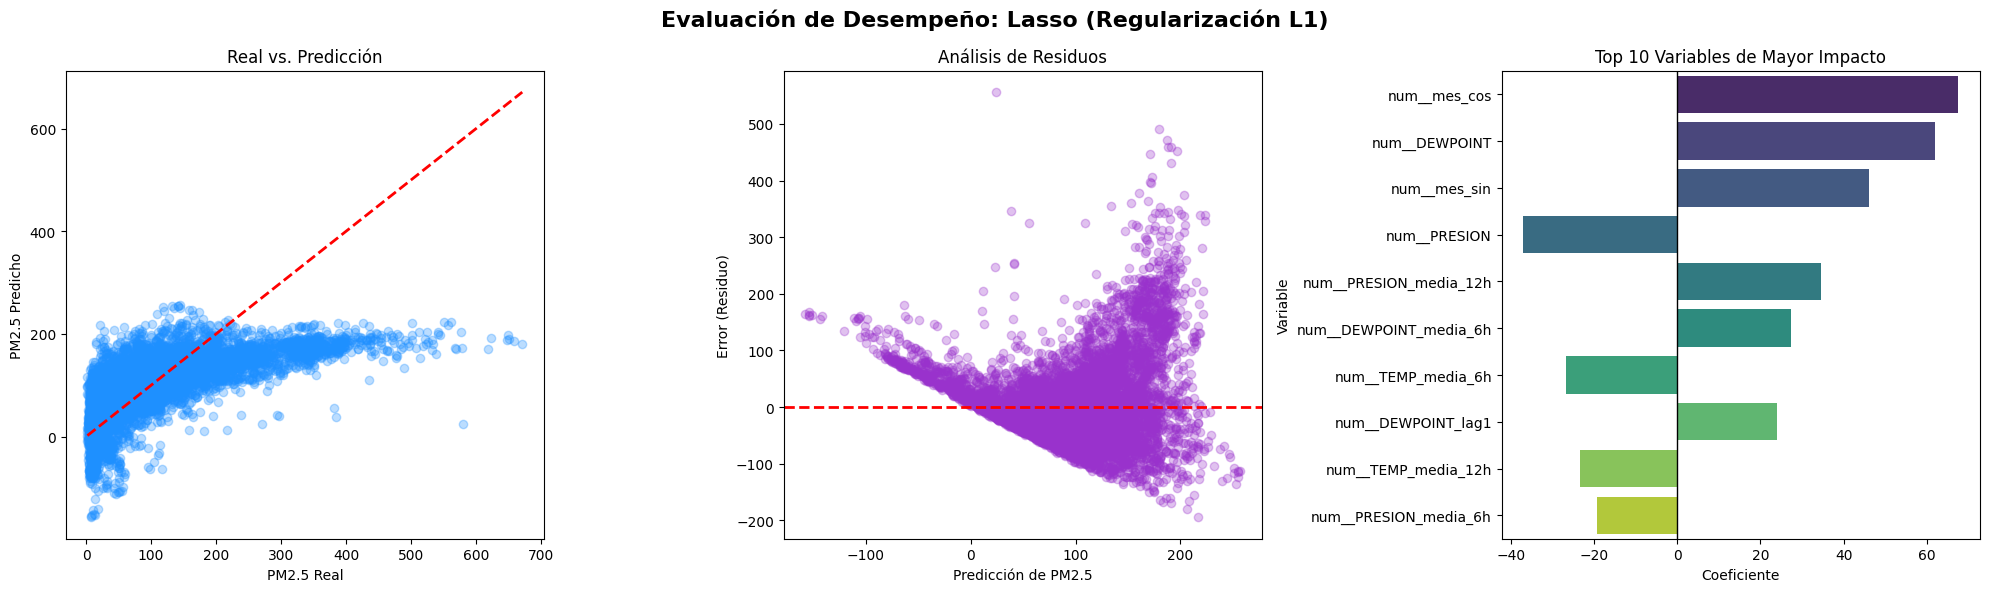

In [12]:
# Evaluamos Lasso
evaluar_modelo_lineal(modelo_final_lasso, X_test, y_test, "Lasso (Regularización L1)")

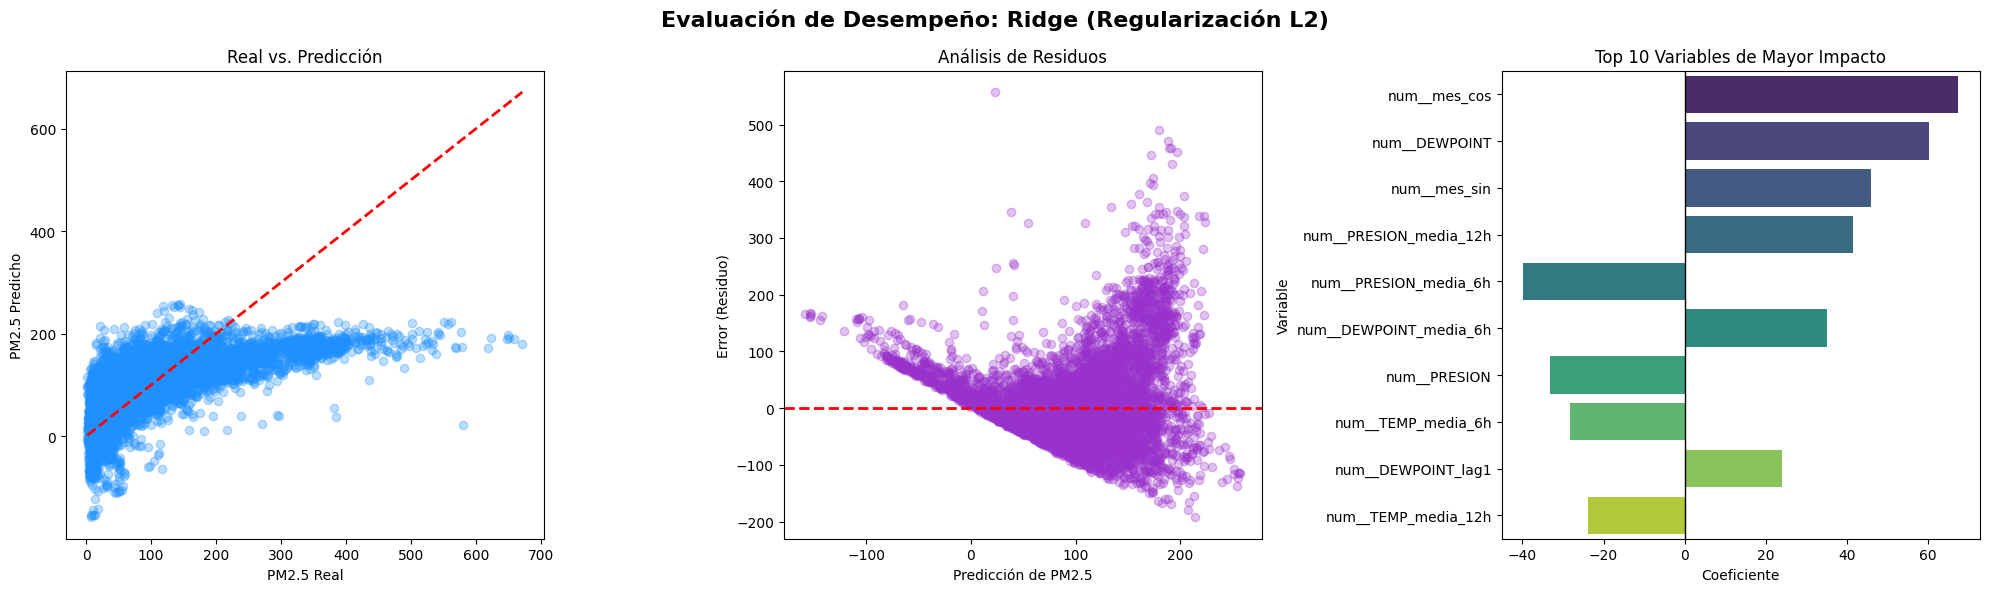

In [13]:
# Evaluamos Ridge
evaluar_modelo_lineal(modelo_final_ridge, X_test, y_test, "Ridge (Regularización L2)")

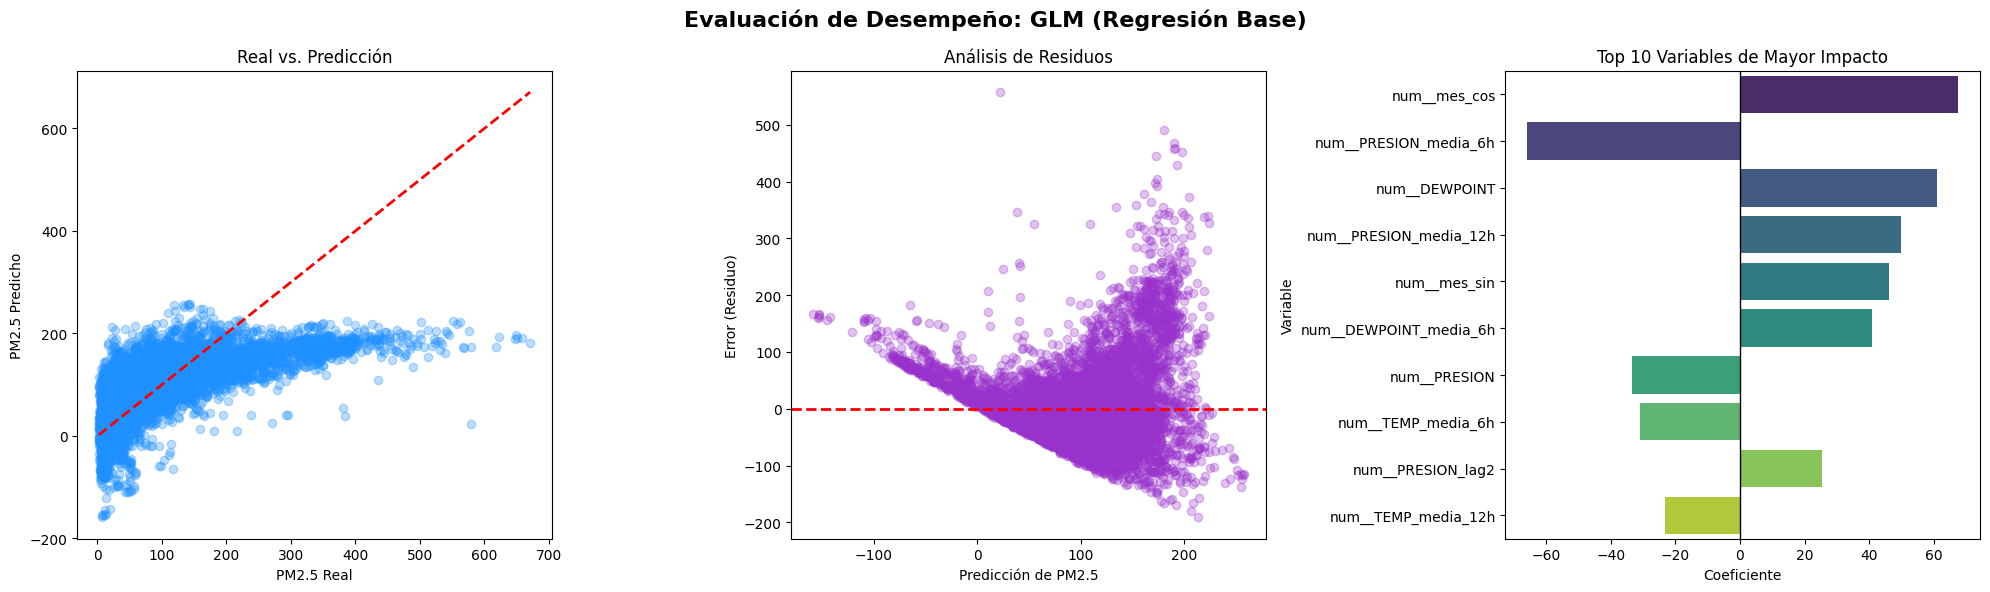

In [14]:
# Evaluamos el GLM
evaluar_modelo_lineal(modelo_final_glm, X_test, y_test, "GLM (Regresión Base)")

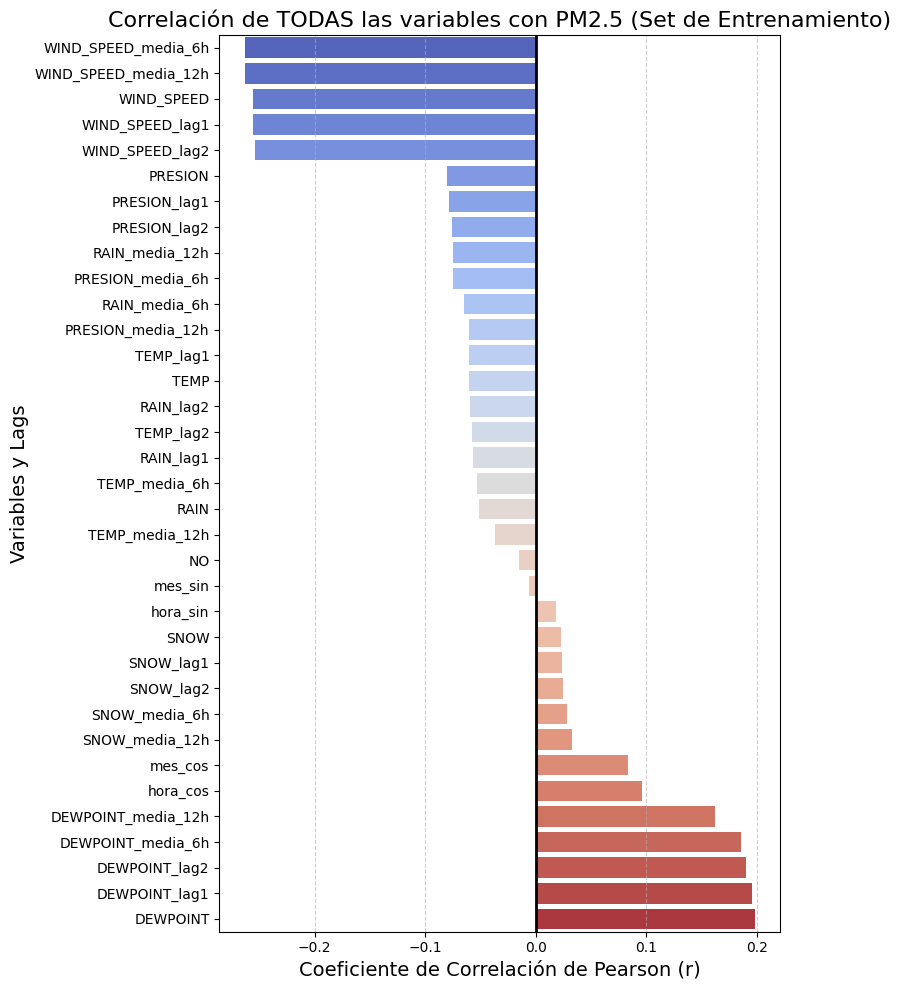

In [15]:
# Analisis de Correlaciones

# Unimos tu guía de estudio (X_train y y_train) temporalmente
datos_entrenamiento = pd.concat([X_train, y_train], axis=1)

# numeric_only=True ignora la columna de texto (viento) automáticamente
correlaciones_pm25 = datos_entrenamiento.corr(numeric_only=True)['PM25'].drop('PM25')

# Ordenamos TODAS las variables (sin recortar nada)
correlaciones_ordenadas = correlaciones_pm25.sort_values(ascending=True)

plt.figure(figsize=(8, 10))

sns.barplot(
    x=correlaciones_ordenadas.values, 
    y=correlaciones_ordenadas.index, 
    hue=correlaciones_ordenadas.index, # Asignamos 'y' a 'hue' como pide la advertencia
    palette="coolwarm", 
    legend=False                       # Apagamos la leyenda automática
)

plt.title('Correlación de TODAS las variables con PM2.5 (Set de Entrenamiento)', fontsize=16)
plt.xlabel('Coeficiente de Correlación de Pearson (r)', fontsize=14)
plt.ylabel('Variables y Lags', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

3. Modelos de Ensamble y Redes

In [18]:
# Funcion para graficar los resultados de los modelos de arboles de desición

def evaluar_modelo_arbol(pipeline, X_test, y_test, nombre_modelo):
    """
    Función que genera los gráficos para modelos basados
    en árboles (Random Forest, XGBoost, AdaBoost).
    """
    # Predicciones y residuos
    predicciones = pipeline.predict(X_test)
    residuos = y_test - predicciones
    
    # Extraemos el modelo y los nombres de las variables
    modelo_puro = pipeline[-1]
    nombres_variables = pipeline['preprocesamiento'].get_feature_names_out()
    
    # Usamos .feature_importances_ en lugar de .coef_ 
    df_importancia = pd.DataFrame({
        'Variable': nombres_variables, 
        'Importancia': modelo_puro.feature_importances_
    })
    
    # Ordenamos para sacar el Top 10
    top_10 = df_importancia.sort_values(by='Importancia', ascending=False).head(10)
    
    # Canvas de los 3 graficos
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Evaluación de Desempeño: {nombre_modelo}', fontsize=16, fontweight='bold')
    
    # Gráfica A: Real vs Predicho
    axes[0].scatter(y_test, predicciones, alpha=0.3, color='dodgerblue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    axes[0].set_title('Real vs. Predicción')
    axes[0].set_xlabel('PM2.5 Real')
    axes[0].set_ylabel('PM2.5 Predicho')
    
    # Gráfica B: Residuos
    axes[1].scatter(predicciones, residuos, alpha=0.3, color='darkorchid')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Análisis de Residuos')
    axes[1].set_xlabel('Predicción de PM2.5')
    axes[1].set_ylabel('Error (Residuo)')
    
    # Gráfica C: Top 10 Importancia
    sns.barplot(
        x='Importancia', 
        y='Variable', 
        data=top_10, 
        ax=axes[2], 
        hue='Variable', 
        palette='magma', 
        legend=False
    )
    axes[2].set_title('Top 10 Variables más Importantes')
    
    plt.tight_layout()
    plt.show()

In [16]:
# XGBoost

# learning_rate=0.1 controla qué tan rápido aprende de los errores de los árboles anteriores
# max_depth=6 limita el tamaño de cada árbol para evitar sobreajuste (overfitting)
modelo_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)

# Conectarlo a tu tubo de procesamiento (preprocessor)
modelo_final_xgb = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_xgb', modelo_xgb)
])

# Entrenando el modelo
display(modelo_final_xgb.fit(X_train, y_train))

# Predicciones
predicciones_xgb = modelo_final_xgb.predict(X_test)

# Evaluar predicciones con la funcion `calculo_errores`
error_xgb = calculo_errores(y_test, predicciones_xgb)

print("====== XGBoost ======")
print(f"RMSE: {error_xgb[0]}")
print(f"MAE: {error_xgb[1]}")
print(f"R² Score: {error_xgb[2]}")

# graficar resultados
evaluar_modelo_arbol(modelo_final_xgb, X_test, y_test, "XGBoost")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo_xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['NO','DEWPOINT','TEMP',...,'WIND_SPEED_media_12h','RAIN_media_12h', 'SNOW_media_12h']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

====== Random Forest ======
RMSE: 101.99677642901658
MAE: 81.0461211053519
R² Score: -0.1703892994001639


In [17]:
# Random Forest

# n_estimators=100 significa que plantaremos 100 árboles de decisión
# n_jobs=-1 le dice a tu computadora que use todos sus núcleos para ir más rápido
bosque = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Conectarlo a tu tubo de procesamiento
modelo_final_rf = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_rf', bosque)
])

# Entrenamiento
display(modelo_final_rf.fit(X_train, y_train))

# predicciones y medir el error
predicciones_rf = modelo_final_rf.predict(X_test)

error_rf = calculo_errores(y_test, predicciones_rf)

print("====== Random Forest ======")
print(f"RMSE: {error_rf[0]}")
print(f"MAE: {error_rf[1]}")
print(f"R² Score: {error_rf[2]}")

# Visualizar resultados
evaluar_modelo_arbol(modelo_final_rf, X_test, y_test, "Random Forest")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo_rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['NO','DEWPOINT','TEMP',...,'WIND_SPEED_media_12h','RAIN_media_12h', 'SNOW_media_12h']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

====== Random Forest ======
RMSE: 92.76782507015635
MAE: 73.1580771072797
R² Score: 0.03182871124359865


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo_ada', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['NO','DEWPOINT','TEMP',...,'WIND_SPEED_media_12h','RAIN_media_12h', 'SNOW_media_12h']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

====== AdaBoost ======
RMSE: 78.69325633272703
MAE: 62.415982826318334
R² Score: 0.30332137888726185


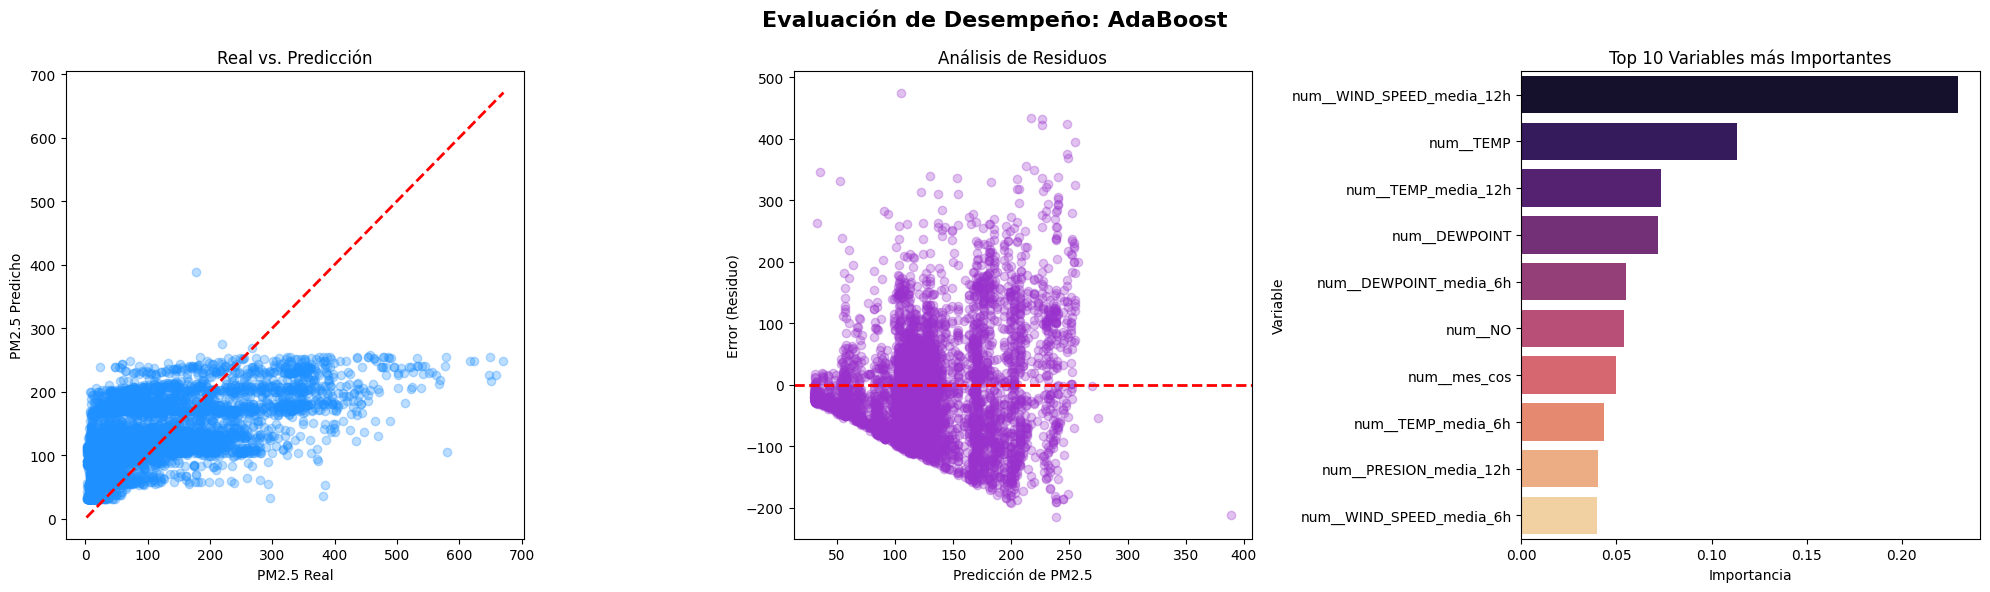

In [26]:
# AdaBoost

# Usamos árboles de decisión pequeños (max_depth=4) como modelo base
modelo_ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42
)

# Conectarlo al Pipeline
modelo_final_ada = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_ada', modelo_ada)
])

# Entrenamiento
display(modelo_final_ada.fit(X_train, y_train))

# Predicción
predicciones_ada = modelo_final_ada.predict(X_test)

# Medición del error
error_ada = calculo_errores(y_test, predicciones_ada)

print("====== AdaBoost ======")
print(f"RMSE: {error_ada[0]}")
print(f"MAE: {error_ada[1]}")
print(f"R² Score: {error_ada[2]}")

# 4. Visualizar con la funcion evaluar_modelo_arbol
evaluar_modelo_arbol(modelo_final_ada, X_test, y_test, "AdaBoost")

In [ ]:
# Redes

